# The Rosen-Roback Spatial Equilibrium Model

This notebook builds up the Rosen-Roback model from first principles. We start with the simplest possible setup and gradually add complexity.

**What we'll cover:**

1. The core intuition: why do wages and rents vary across cities?
2. A two-city model with mobile workers
3. Adding firms and productivity differences
4. The full Rosen-Roback equilibrium
5. What happens when housing supply is constrained?
6. Applying the model to real data


In [ ]:
from dataclasses import dataclass
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set style for plots
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## Part 1: The Core Intuition

### Why do wages and rents differ across cities?

Consider two facts:

- London wages are ~30% higher than the UK average
- London rents are ~3x the UK average

Why would anyone live in London? The wages don't seem to compensate for the rent!

The Rosen-Roback model answers this by recognising that **locations differ in ways beyond just wages and rents**:

- **Amenities**: restaurants, culture, weather, scenery
- **Productivity**: some places make workers more productive (agglomeration)

In equilibrium, workers must be **indifferent** between locations. If one city were strictly better, everyone would move there.


## Part 2: A Simple Model with Mobile Workers

Let's start with the simplest possible model:

### Setup

- Two cities: A and B
- Workers are **perfectly mobile** (can move costlessly)
- Workers care about **wages** $w$ and **rents** $r$
- Each city has some **amenity value** $a$

### Worker utility

A worker in city $i$ gets utility:

$$V_i = w_i - r_i + a_i$$

This is a simple linear specification. The worker earns $w_i$, pays rent $r_i$, and enjoys amenities worth $a_i$.

### Spatial equilibrium condition

If workers can move freely, in equilibrium:

$$V_A = V_B$$

Otherwise, workers would move from the low-utility city to the high-utility city.


In [13]:
@dataclass
class City:
    """A city with wages, rents, and amenities."""

    name: str
    wage: float
    rent: float
    amenity: float

    @property
    def utility(self) -> float:
        """Worker utility in this city."""
        return self.wage - self.rent + self.amenity


# Example: Two cities
london = City(name="London", wage=45000, rent=20000, amenity=5000)
manchester = City(name="Manchester", wage=35000, rent=8000, amenity=3000)

print(f"{london.name}:")
print(f"  Wage: £{london.wage:,}")
print(f"  Rent: £{london.rent:,}")
print(f"  Amenity value: £{london.amenity:,}")
print(f"  Utility: £{london.utility:,}")
print()
print(f"{manchester.name}:")
print(f"  Wage: £{manchester.wage:,}")
print(f"  Rent: £{manchester.rent:,}")
print(f"  Amenity value: £{manchester.amenity:,}")
print(f"  Utility: £{manchester.utility:,}")

London:
  Wage: £45,000
  Rent: £20,000
  Amenity value: £5,000
  Utility: £30,000

Manchester:
  Wage: £35,000
  Rent: £8,000
  Amenity value: £3,000
  Utility: £30,000


### Interpretation

In this example, both cities give the same utility (£30,000). This is spatial equilibrium!

London has:

- Higher wages (+£10,000)
- But much higher rents (+£12,000)
- And better amenities (+£2,000)

The net effect: workers are indifferent.

**Key insight**: High rents in London are not a "bug" - they're the price of access to London's amenities and job market. Rents adjust until workers are indifferent.


## Part 3: Adding Housing Supply

Where do rents come from? Let's add a housing market.

### Housing supply

Each city has a housing supply function:

$$H_i = S_i \cdot r_i^{\gamma_i}$$

where:

- $H_i$ = housing units supplied
- $S_i$ = supply shifter (land availability, regulations)
- $r_i$ = rent
- $\gamma_i$ = supply elasticity

**Supply elasticity** $\gamma$ is crucial:

- High $\gamma$: Housing supply responds strongly to prices (e.g., Houston)
- Low $\gamma$: Housing supply is inelastic (e.g., San Francisco, London)

### Housing demand

Assume each worker needs one housing unit, so housing demand equals population $L_i$.

### Equilibrium

Housing market clears: $H_i = L_i$

Solving for rent:
$$r_i = \left(\frac{L_i}{S_i}\right)^{1/\gamma_i}$$


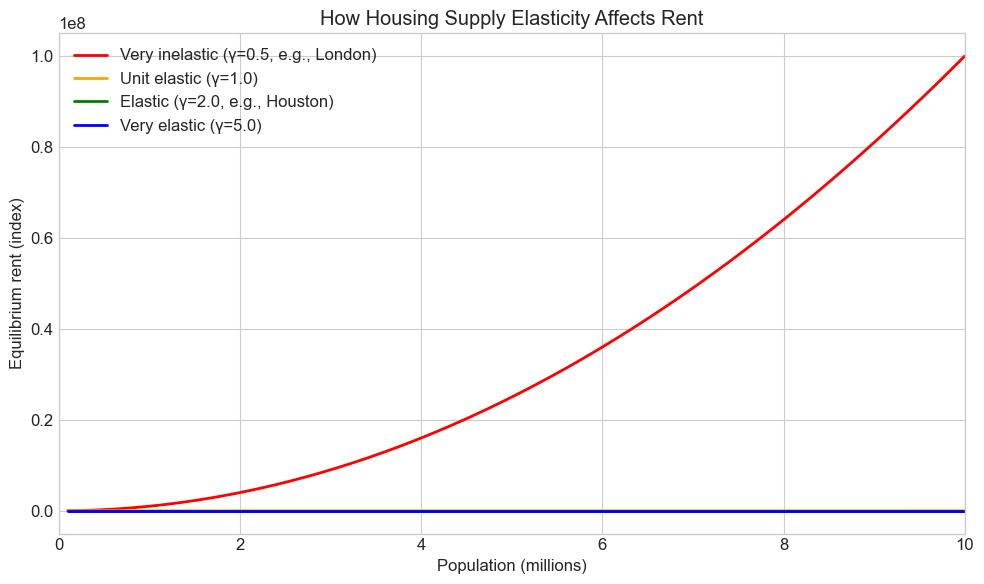

In [3]:
def equilibrium_rent(population: float, supply_shifter: float, elasticity: float) -> float:
    """Calculate equilibrium rent given population and housing supply parameters."""
    return (population / supply_shifter) ** (1 / elasticity)


# Demonstrate how elasticity affects rent response to population
populations = np.linspace(100_000, 10_000_000, 100)
supply_shifter = 1000  # Normalize

fig, ax = plt.subplots(figsize=(10, 6))

for gamma, label, color in [
    (0.5, "Very inelastic (γ=0.5, e.g., London)", "red"),
    (1.0, "Unit elastic (γ=1.0)", "orange"),
    (2.0, "Elastic (γ=2.0, e.g., Houston)", "green"),
    (5.0, "Very elastic (γ=5.0)", "blue"),
]:
    rents = [equilibrium_rent(p, supply_shifter, gamma) for p in populations]
    ax.plot(populations / 1e6, rents, label=label, color=color, linewidth=2)

ax.set_xlabel("Population (millions)")
ax.set_ylabel("Equilibrium rent (index)")
ax.set_title("How Housing Supply Elasticity Affects Rent")
ax.legend()
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

### Key insight

When housing supply is **inelastic** (low $\gamma$):

- Population growth causes rents to spike
- Small increases in demand → large rent increases

When housing supply is **elastic** (high $\gamma$):

- Population can grow with modest rent increases
- The city can absorb more people

This is the heart of the housing debate: **restrictive planning makes housing supply inelastic**.


## Part 4: Adding Firms and Productivity

So far, wages are exogenous. Let's add firms.

### Firm production

Firms produce output using labour:

$$Y_i = A_i \cdot L_i^\alpha$$

where:

- $Y_i$ = output
- $A_i$ = total factor productivity (TFP)
- $L_i$ = labour (workers)
- $\alpha$ = labour share (typically 0.6-0.7)

### Agglomeration

Here's the crucial addition: **productivity increases with city size**:

$$A_i = \bar{A}_i \cdot L_i^\eta$$

where $\eta > 0$ is the **agglomeration elasticity**.

Why does agglomeration occur?

- Knowledge spillovers (learn from others)
- Labour market matching (find the right job/worker)
- Input sharing (specialized suppliers)

Empirically, $\eta \approx 0.02-0.08$ (doubling city size increases productivity by 2-8%).

### Wage determination

With competitive labour markets, wage equals marginal product:

$$w_i = \alpha \cdot A_i \cdot L_i^{\alpha - 1} = \alpha \cdot \bar{A}_i \cdot L_i^{\alpha + \eta - 1}$$


In [ ]:
@dataclass
class ProductionParams:
    """Parameters for production function."""

    alpha: float = 0.65  # Labour share
    eta: float = 0.04  # Agglomeration elasticity


def calculate_wage(population: float, base_tfp: float, params: ProductionParams) -> float:
    """Calculate equilibrium wage given population and TFP."""
    # Productivity with agglomeration
    tfp = base_tfp * (population**params.eta)
    # Marginal product of labour
    wage = params.alpha * tfp * (population ** (params.alpha - 1))
    return wage


def calculate_output(population: float, base_tfp: float, params: ProductionParams) -> float:
    """Calculate total output."""
    tfp = base_tfp * (population**params.eta)
    return tfp * (population**params.alpha)


# Demonstrate agglomeration effects
production_params = ProductionParams(alpha=0.65, eta=0.04)
base_tfp = 100

populations = np.array([100_000, 500_000, 1_000_000, 5_000_000, 10_000_000])

print("Effect of city size on productivity and wages:")
print("-" * 60)
print(f"{'Population':>12} {'TFP':>10} {'Wage':>12} {'Wage ratio':>12}")
print("-" * 60)

base_wage = calculate_wage(populations[0], base_tfp, production_params)
for pop in populations:
    tfp = base_tfp * (pop**production_params.eta)
    wage = calculate_wage(pop, base_tfp, production_params)
    print(f"{pop:>12,} {tfp:>10.1f} {wage:>12.2f} {wage / base_wage:>12.2f}x")

Effect of city size on productivity and wages:
------------------------------------------------------------
  Population        TFP         Wage   Wage ratio
------------------------------------------------------------
     100,000      158.5         1.83         1.00x
     500,000      169.0         1.11         0.61x
   1,000,000      173.8         0.90         0.49x
   5,000,000      185.3         0.54         0.30x
  10,000,000      190.5         0.44         0.24x


### Key insight

With agglomeration ($\eta > 0$), larger cities are **more productive**. This creates a force pulling workers toward big cities.

But there's a counterforce: as cities grow, **rents rise** (especially with inelastic housing supply).

The equilibrium balances these forces.


## Part 5: The Full Rosen-Roback Model

Now let's put it all together into a complete model with multiple cities.

### Model components

**Workers:**

- Utility: $V_i = \frac{w_i}{r_i^\beta}$ (CES formulation, where $\beta$ is housing expenditure share)
- Spatial equilibrium: $V_i = \bar{V}$ for all cities

**Firms:**

- Production: $Y_i = A_i L_i^\alpha$ with $A_i = \bar{A}_i L_i^\eta$
- Zero profit condition determines wages

**Housing:**

- Supply: $H_i = S_i r_i^{\gamma_i}$
- Demand: $H_i = L_i$

**Labour market:**

- Total labour fixed: $\sum_i L_i = \bar{L}$


In [5]:
@dataclass
class ModelParams:
    """Full model parameters."""

    alpha: float = 0.65  # Labour share
    eta: float = 0.04  # Agglomeration elasticity
    beta: float = 0.33  # Housing expenditure share
    theta: float = 3.0  # Labour mobility (Frechet shape parameter)


@dataclass
class CityParams:
    """City-specific parameters."""

    name: str
    base_tfp: float  # Base productivity
    amenity: float  # Amenity value
    supply_elasticity: float  # Housing supply elasticity
    supply_shifter: float  # Housing supply shifter


class RosenRobackModel:
    """
    Multi-city Rosen-Roback spatial equilibrium model.

    Uses log-space calculations for numerical stability.
    """

    def __init__(self, params: ModelParams, cities: list[CityParams]):
        self.params = params
        self.cities = cities
        self.n_cities = len(cities)

        # Pre-compute log of city-specific parameters
        self.log_base_tfp = np.array([np.log(c.base_tfp) for c in cities])
        self.log_amenity = np.array([np.log(c.amenity) for c in cities])
        self.supply_elasticity = np.array([c.supply_elasticity for c in cities])
        self.log_supply_shifter = np.array([np.log(c.supply_shifter) for c in cities])

    def log_rent_from_log_population(self, log_pop: np.ndarray) -> np.ndarray:
        """Calculate log rents given log population distribution."""
        return (log_pop - self.log_supply_shifter) / self.supply_elasticity

    def log_wage_from_log_population(self, log_pop: np.ndarray) -> np.ndarray:
        """Calculate log wages given log population distribution."""
        p = self.params
        return np.log(p.alpha) + self.log_base_tfp + (p.alpha + p.eta - 1) * log_pop

    def log_utility(self, log_wages: np.ndarray, log_rents: np.ndarray) -> np.ndarray:
        """Calculate log utility in each city."""
        return log_wages - self.params.beta * log_rents + self.log_amenity

    def log_output(self, log_pop: np.ndarray) -> np.ndarray:
        """Calculate log output in each city."""
        return self.log_base_tfp + (self.params.alpha + self.params.eta) * log_pop

    def _logsumexp(self, x: np.ndarray) -> float:
        """Numerically stable log-sum-exp."""
        c = x.max()
        return c + np.log(np.sum(np.exp(x - c)))

    def solve_equilibrium(
        self, total_population: float, tol: float = 1e-8, max_iter: int = 2000, damping: float = 0.3
    ) -> dict:
        """
        Solve for spatial equilibrium using iterative adjustment.

        Workers flow toward high-utility cities until utilities equalize.
        Uses damping and adaptive step sizes for stability.
        """
        # Initial guess: equal distribution (in log space)
        log_total_pop = np.log(total_population)
        log_pop = np.full(self.n_cities, log_total_pop - np.log(self.n_cities))

        # Adaptive damping for high theta
        effective_damping = min(damping, 1.0 / (1.0 + self.params.theta / 10.0))

        for iteration in range(max_iter):
            # Calculate wages and rents in log space
            log_rents = self.log_rent_from_log_population(log_pop)
            log_wages = self.log_wage_from_log_population(log_pop)
            log_utilities = self.log_utility(log_wages, log_rents)

            # Workers move toward high-utility cities
            # share_i ∝ utility_i^theta
            log_shares_unnorm = self.params.theta * log_utilities
            log_sum = self._logsumexp(log_shares_unnorm)
            log_shares = log_shares_unnorm - log_sum

            # New population (ensure it sums to total)
            new_log_pop = log_shares + log_total_pop

            # Damped update for stability
            new_log_pop = effective_damping * new_log_pop + (1 - effective_damping) * log_pop

            # Check convergence on population shares
            old_shares = np.exp(log_pop - self._logsumexp(log_pop))
            new_shares = np.exp(new_log_pop - self._logsumexp(new_log_pop))
            diff = np.abs(new_shares - old_shares).max()

            log_pop = new_log_pop

            if diff < tol:
                break

        # Final calculations (convert back from log space)
        population = np.exp(log_pop)
        # Renormalize to ensure exact total
        population = population * (total_population / population.sum())

        log_pop = np.log(population)
        log_rents = self.log_rent_from_log_population(log_pop)
        log_wages = self.log_wage_from_log_population(log_pop)
        log_utilities = self.log_utility(log_wages, log_rents)
        log_outputs = self.log_output(log_pop)

        rents = np.exp(log_rents)
        wages = np.exp(log_wages)
        utilities = np.exp(log_utilities)
        outputs = np.exp(log_outputs)

        return {
            "population": population,
            "wages": wages,
            "rents": rents,
            "utilities": utilities,
            "outputs": outputs,
            "total_output": outputs.sum(),
            "iterations": iteration + 1,
            "converged": iteration + 1 < max_iter,
        }

In [6]:
# Create a simple three-city example
params = ModelParams(alpha=0.65, eta=0.04, beta=0.33, theta=3.0)

cities = [
    CityParams(
        name="High Productivity City",
        base_tfp=120,
        amenity=1.0,
        supply_elasticity=1.5,
        supply_shifter=1000,
    ),
    CityParams(
        name="Medium City",
        base_tfp=100,
        amenity=1.0,
        supply_elasticity=2.0,
        supply_shifter=1000,
    ),
    CityParams(
        name="Low Productivity City",
        base_tfp=80,
        amenity=1.0,
        supply_elasticity=3.0,
        supply_shifter=1000,
    ),
]

model = RosenRobackModel(params, cities)
result = model.solve_equilibrium(total_population=3_000_000)

# Display results
print("Spatial Equilibrium Results")
print("=" * 70)
print(f"{'City':<25} {'Population':>12} {'Wage':>10} {'Rent':>10} {'Utility':>10}")
print("-" * 70)
for i, city in enumerate(cities):
    print(
        f"{city.name:<25} {result['population'][i]:>12,.0f} {result['wages'][i]:>10.2f} {result['rents'][i]:>10.2f} {result['utilities'][i]:>10.2f}"
    )
print("-" * 70)
print(f"Total output: {result['total_output']:,.0f}")
print(f"Converged in {result['iterations']} iterations")

Spatial Equilibrium Results
City                        Population       Wage       Rent    Utility
----------------------------------------------------------------------
High Productivity City         788,912       1.16      85.38       0.27
Medium City                    991,265       0.90      31.48       0.29
Low Productivity City        1,219,822       0.67      10.68       0.31
----------------------------------------------------------------------
Total output: 4,045,111
Converged in 31 iterations


### Visualizing the equilibrium


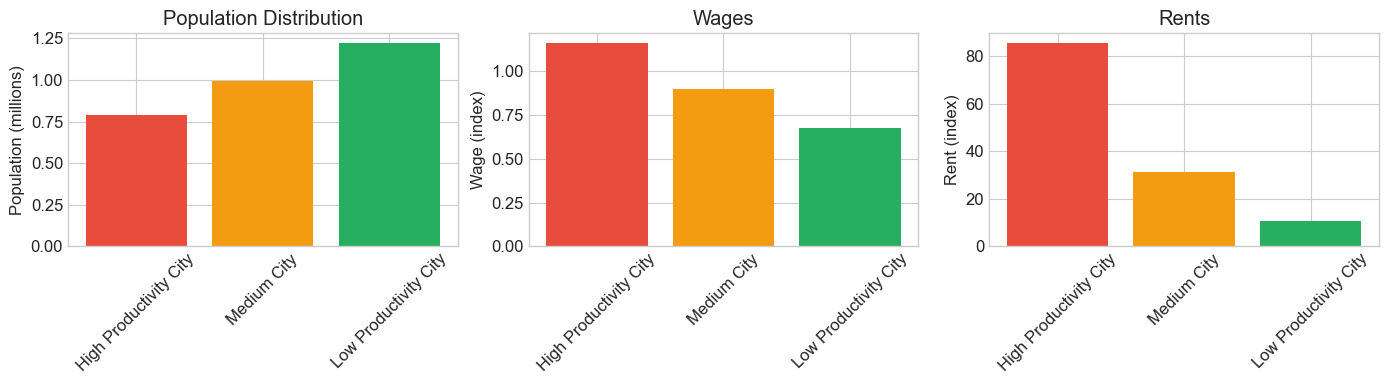


Utilities (approximately equal in probabilistic equilibrium):
  High Productivity City: 0.2671
  Medium City: 0.2882
  Low Productivity City: 0.3089

--- Effect of mobility parameter θ on utility spread ---
Higher θ = more mobile workers = utilities converge closer to equality

  θ= 1.0: utility spread = 27.08%
  θ= 2.0: utility spread = 19.83%
  θ= 3.0: utility spread = 15.64%
  θ= 5.0: utility spread = 10.98%
  θ=10.0: utility spread =  6.29%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

city_names = [c.name for c in cities]
colors = ["#e74c3c", "#f39c12", "#27ae60"]

# Population
axes[0].bar(city_names, result["population"] / 1e6, color=colors)
axes[0].set_ylabel("Population (millions)")
axes[0].set_title("Population Distribution")
axes[0].tick_params(axis="x", rotation=45)

# Wages
axes[1].bar(city_names, result["wages"], color=colors)
axes[1].set_ylabel("Wage (index)")
axes[1].set_title("Wages")
axes[1].tick_params(axis="x", rotation=45)

# Rents
axes[2].bar(city_names, result["rents"], color=colors)
axes[2].set_ylabel("Rent (index)")
axes[2].set_title("Rents")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Utility check - note: not perfectly equal because we use probabilistic model
print("\nUtilities (approximately equal in probabilistic equilibrium):")
for i, city in enumerate(cities):
    print(f"  {city.name}: {result['utilities'][i]:.4f}")

# Show how theta affects utility equalization
print("\n--- Effect of mobility parameter θ on utility spread ---")
print("Higher θ = more mobile workers = utilities converge closer to equality\n")
for theta_val in [1.0, 2.0, 3.0, 5.0, 10.0]:
    test_params = ModelParams(alpha=0.65, eta=0.04, beta=0.33, theta=theta_val)
    test_model = RosenRobackModel(test_params, cities)
    test_result = test_model.solve_equilibrium(total_population=3_000_000)
    util_spread = test_result["utilities"].max() / test_result["utilities"].min() - 1
    print(f"  θ={theta_val:4.1f}: utility spread = {util_spread * 100:5.2f}%")

## Part 6: The Cost of Housing Constraints

Now we can ask the key question: **what happens if we restrict housing supply in the productive city?**

Let's compare:

1. **Baseline**: All cities have reasonable supply elasticity
2. **Constrained**: The high-productivity city has very inelastic supply


In [8]:
def run_scenario(supply_elasticity_high_prod: float, label: str) -> dict:
    """Run model with given supply elasticity for high-productivity city."""
    cities = [
        CityParams(
            name="High Productivity",
            base_tfp=120,
            amenity=1.0,
            supply_elasticity=supply_elasticity_high_prod,  # This varies
            supply_shifter=1000,
        ),
        CityParams(
            name="Medium",
            base_tfp=100,
            amenity=1.0,
            supply_elasticity=2.0,
            supply_shifter=1000,
        ),
        CityParams(
            name="Low Productivity",
            base_tfp=80,
            amenity=1.0,
            supply_elasticity=3.0,
            supply_shifter=1000,
        ),
    ]

    model = RosenRobackModel(params, cities)
    result = model.solve_equilibrium(total_population=3_000_000)
    result["label"] = label
    result["cities"] = cities
    return result


# Run scenarios
scenarios = [
    run_scenario(3.0, "Elastic supply (γ=3.0)"),
    run_scenario(2.0, "Moderate (γ=2.0)"),
    run_scenario(1.0, "Inelastic (γ=1.0)"),
    run_scenario(0.5, "Very inelastic (γ=0.5)"),
]

# Compare outcomes
print("Effect of Housing Supply Constraints on High-Productivity City")
print("=" * 80)
print(f"{'Scenario':<25} {'HP Pop':>12} {'HP Rent':>10} {'Total GDP':>12} {'GDP vs Elastic':>15}")
print("-" * 80)

baseline_gdp = scenarios[0]["total_output"]
for s in scenarios:
    gdp_change = (s["total_output"] / baseline_gdp - 1) * 100
    print(
        f"{s['label']:<25} {s['population'][0]:>12,.0f} {s['rents'][0]:>10.2f} {s['total_output']:>12,.0f} {gdp_change:>14.1f}%"
    )

Effect of Housing Supply Constraints on High-Productivity City
Scenario                        HP Pop    HP Rent    Total GDP  GDP vs Elastic
--------------------------------------------------------------------------------
Elastic supply (γ=3.0)       1,449,177      11.32    4,208,030            0.0%
Moderate (γ=2.0)             1,082,884      32.91    4,142,471           -1.6%
Inelastic (γ=1.0)              419,888     419.89    3,843,798           -8.7%
Very inelastic (γ=0.5)          97,596    9525.03    3,513,041          -16.5%


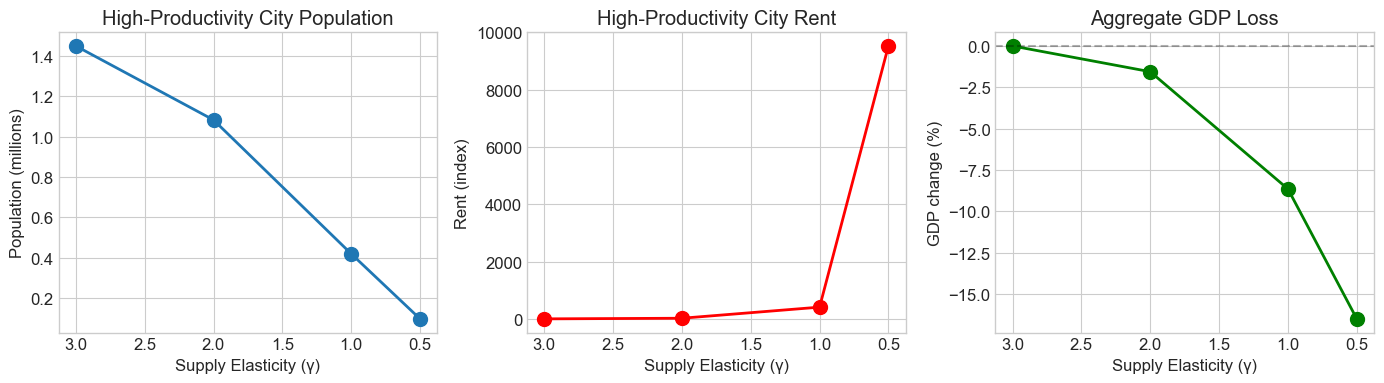

In [9]:
# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

elasticities = [3.0, 2.0, 1.0, 0.5]
high_prod_pop = [s["population"][0] for s in scenarios]
high_prod_rent = [s["rents"][0] for s in scenarios]
total_gdp = [s["total_output"] for s in scenarios]

# Population in high-productivity city
axes[0].plot(elasticities, np.array(high_prod_pop) / 1e6, "o-", markersize=10, linewidth=2)
axes[0].set_xlabel("Supply Elasticity (γ)")
axes[0].set_ylabel("Population (millions)")
axes[0].set_title("High-Productivity City Population")
axes[0].invert_xaxis()  # Lower elasticity = more constrained

# Rent in high-productivity city
axes[1].plot(elasticities, high_prod_rent, "o-", markersize=10, linewidth=2, color="red")
axes[1].set_xlabel("Supply Elasticity (γ)")
axes[1].set_ylabel("Rent (index)")
axes[1].set_title("High-Productivity City Rent")
axes[1].invert_xaxis()

# Total GDP
gdp_pct = (np.array(total_gdp) / total_gdp[0] - 1) * 100
axes[2].plot(elasticities, gdp_pct, "o-", markersize=10, linewidth=2, color="green")
axes[2].set_xlabel("Supply Elasticity (γ)")
axes[2].set_ylabel("GDP change (%)")
axes[2].set_title("Aggregate GDP Loss")
axes[2].axhline(y=0, color="black", linestyle="--", alpha=0.3)
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()

### Key insight: Spatial Misallocation

When housing supply is constrained in the high-productivity city:

1. **Rents spike** - the limited housing goes to highest bidders
2. **Workers are pushed out** - high rents offset the productivity advantage
3. **GDP falls** - workers end up in less productive locations

This is the core mechanism in Hsieh-Moretti and similar papers. **Restrictive planning in productive cities reduces national output.**


## Part 7: Sensitivity Analysis

How sensitive are these results to our parameter choices? Let's explore.


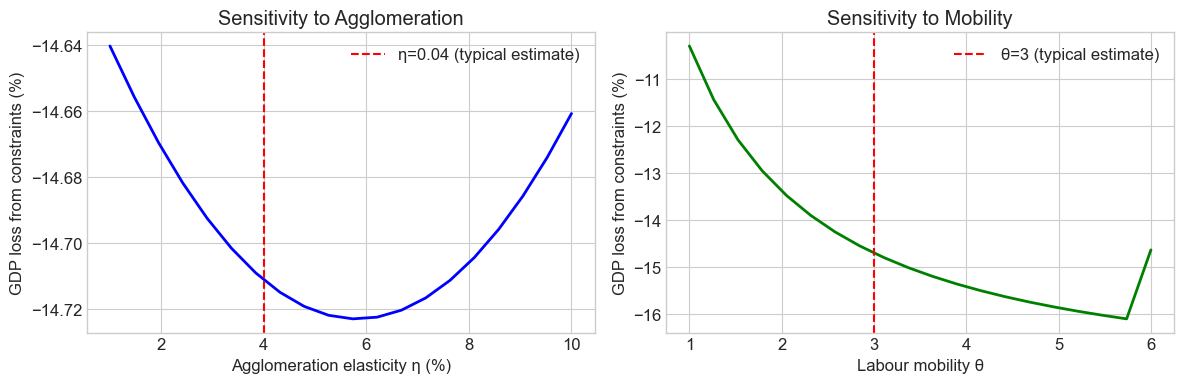

In [10]:
def calculate_gdp_loss(eta: float, theta: float, constrained_gamma: float = 0.5) -> float:
    """Calculate GDP loss from housing constraints given parameters."""
    params = ModelParams(alpha=0.65, eta=eta, beta=0.33, theta=theta)

    # Baseline: elastic supply
    cities_baseline = [
        CityParams("HP", 120, 1.0, 2.0, 1000),
        CityParams("M", 100, 1.0, 2.0, 1000),
        CityParams("LP", 80, 1.0, 2.0, 1000),
    ]
    model_baseline = RosenRobackModel(params, cities_baseline)
    result_baseline = model_baseline.solve_equilibrium(3_000_000)

    # Constrained: inelastic supply in HP city
    cities_constrained = [
        CityParams("HP", 120, 1.0, constrained_gamma, 1000),
        CityParams("M", 100, 1.0, 2.0, 1000),
        CityParams("LP", 80, 1.0, 2.0, 1000),
    ]
    model_constrained = RosenRobackModel(params, cities_constrained)
    result_constrained = model_constrained.solve_equilibrium(3_000_000)

    gdp_loss = (result_constrained["total_output"] / result_baseline["total_output"] - 1) * 100
    return gdp_loss


# Sensitivity to agglomeration elasticity (eta)
etas = np.linspace(0.01, 0.10, 20)
gdp_losses_eta = [calculate_gdp_loss(eta=e, theta=3.0) for e in etas]

# Sensitivity to labour mobility (theta)
thetas = np.linspace(1.0, 6.0, 20)
gdp_losses_theta = [calculate_gdp_loss(eta=0.04, theta=t) for t in thetas]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(etas * 100, gdp_losses_eta, "b-", linewidth=2)
axes[0].axvline(x=4, color="red", linestyle="--", label="η=0.04 (typical estimate)")
axes[0].set_xlabel("Agglomeration elasticity η (%)")
axes[0].set_ylabel("GDP loss from constraints (%)")
axes[0].set_title("Sensitivity to Agglomeration")
axes[0].legend()

axes[1].plot(thetas, gdp_losses_theta, "g-", linewidth=2)
axes[1].axvline(x=3.0, color="red", linestyle="--", label="θ=3 (typical estimate)")
axes[1].set_xlabel("Labour mobility θ")
axes[1].set_ylabel("GDP loss from constraints (%)")
axes[1].set_title("Sensitivity to Mobility")
axes[1].legend()

plt.tight_layout()
plt.show()

### Key findings from sensitivity analysis

1. **Agglomeration elasticity (η)**: Higher agglomeration → larger GDP losses from constraints
   - Makes sense: if big cities are much more productive, keeping people out is more costly
2. **Labour mobility (θ)**: Higher mobility → larger GDP losses
   - When workers are very mobile, they respond strongly to utility differences
   - But with constraints, high rents push them to less productive cities


## Part 8: The Rosen-Roback Diagram

A classic way to visualise the model is the **wage-rent diagram**. Cities with:

- High wages + high rents → high productivity
- Low wages + low rents → low productivity or low amenities
- High rents + low wages → high amenities (people pay to live there)
- Low rents + high wages → low amenities (have to pay people to live there)


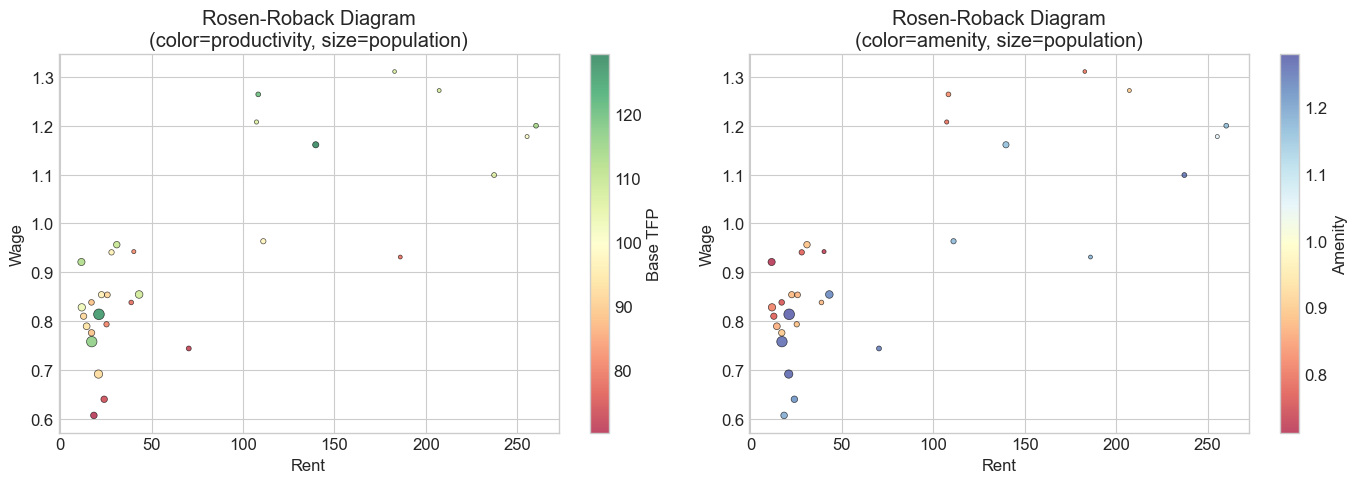

In [11]:
# Create a larger set of cities with varying productivity and amenities
np.random.seed(42)
n_cities = 30

# Generate random cities
random_cities = []
for i in range(n_cities):
    base_tfp = np.random.uniform(70, 130)
    amenity = np.random.uniform(0.7, 1.3)
    gamma = np.random.uniform(1.0, 3.0)
    random_cities.append(
        CityParams(
            name=f"City_{i}",
            base_tfp=base_tfp,
            amenity=amenity,
            supply_elasticity=gamma,
            supply_shifter=1000,
        )
    )

# Solve equilibrium
model = RosenRobackModel(ModelParams(), random_cities)
result = model.solve_equilibrium(total_population=30_000_000)

# Create DataFrame for plotting
df = pd.DataFrame(
    {
        "city": [c.name for c in random_cities],
        "productivity": [c.base_tfp for c in random_cities],
        "amenity": [c.amenity for c in random_cities],
        "population": result["population"],
        "wage": result["wages"],
        "rent": result["rents"],
    }
)

# Rosen-Roback diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wage-Rent scatter, colored by productivity
sc1 = axes[0].scatter(
    df["rent"],
    df["wage"],
    c=df["productivity"],
    cmap="RdYlGn",
    s=df["population"] / 50000,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.5,
)
axes[0].set_xlabel("Rent")
axes[0].set_ylabel("Wage")
axes[0].set_title("Rosen-Roback Diagram\n(color=productivity, size=population)")
plt.colorbar(sc1, ax=axes[0], label="Base TFP")

# Same but colored by amenity
sc2 = axes[1].scatter(
    df["rent"],
    df["wage"],
    c=df["amenity"],
    cmap="RdYlBu",
    s=df["population"] / 50000,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.5,
)
axes[1].set_xlabel("Rent")
axes[1].set_ylabel("Wage")
axes[1].set_title("Rosen-Roback Diagram\n(color=amenity, size=population)")
plt.colorbar(sc2, ax=axes[1], label="Amenity")

plt.tight_layout()
plt.show()

### Reading the Rosen-Roback Diagram

**Left panel (productivity):**

- High-productivity cities (green) have high wages and high rents
- The upward-sloping pattern shows productivity → wages → rents

**Right panel (amenity):**

- High-amenity cities (blue) have higher rents _for a given wage_
- People accept lower real wages to live in nice places

This is the power of the Rosen-Roback framework: **observed wages and rents reveal unobserved amenities and productivity**.


## Summary

We've built up the Rosen-Roback model from first principles:

1. **Workers are mobile** → utilities must equalize across cities
2. **Housing supply matters** → inelastic supply means rents spike with demand
3. **Agglomeration exists** → big cities are more productive
4. **Housing constraints cause GDP losses** → workers are pushed to less productive places

**Key parameters:**

- $\eta$ (agglomeration): ~2-8% productivity gain from doubling city size
- $\gamma$ (supply elasticity): varies hugely across cities (Houston ~3, San Francisco ~0.5)
- $\theta$ (mobility): ~2-4 in most estimates

**Next steps:**

- Apply to real US/UK data
- Compare to Hsieh-Moretti estimates
- Discuss the Greaney critique and Duranton-Puga alternative
